# `br-ue` — Boundedly-rational user equilibrium (Mahmassani & Chang 1987)

**What.** Boundedly-rational UE relaxes Wardrop's equality to an *indifference band*:
a flow is acceptable if every used route is within an absolute threshold ε of its
OD's cheapest route. The equilibrium is therefore a SET, not a point — `br-ue` returns
the band-edge flow reached from the free-flow all-or-nothing start
(`[mahmassani1987on]`, [docs/REFERENCES.md](../../docs/REFERENCES.md)).

**Why it is in the benchmark.** It is the behavioural relaxation of exact rationality
(ADR-008): the scored certificate becomes band-acceptability, not a zero gap. See the
[model compendium](../../docs/MODELS.md) and
[docs/ARCHITECTURE.md](../../docs/ARCHITECTURE.md) (P1).

**Scope.** Runs on the built-in BR two-route anchor (demand 10, ε = 1) and certifies
band-acceptability. Its Wardrop gap is deliberately non-zero — that is the point.

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every scored
quantity below is recomputed live by the P1 `Evaluator` from the flows the model
emitted, in the cell where it is claimed. Model self-reports are shown only as
provenance and diffed against the certificate as an honesty check, exactly as the
harness treats them ([README](../../README.md), *Certified, not self-reported*).

In [1]:
# Setup. `br-ue` is a core model: a plain `pip install -e .` suffices — no
# optional extra, so no guard cell. The inline backend is Agg-based (headless CI
# renders into the notebook); NEVER matplotlib.use("Agg") in-kernel — it silently
# suppresses inline figure capture.
%matplotlib inline
import numpy as np

from tabench import (
    BoundedlyRationalUEModel,
    Budget,
    Evaluator,
    RngBundle,
    Trace,
    br_two_route_scenario,
    viz,
)

## The scenario

Two disjoint 2-link routes, demand 10, indifference band ε = 1 (native cost units).
Both route slopes are 1, so the acceptable set is an interval around the Wardrop split;
the free-flow-AON swap stops at the band edge f_A = (D+1)/2 + ε/2 = 6. Content-hashed (P2).

In [2]:
scenario = br_two_route_scenario()
net = scenario.network

print(f"scenario      : {scenario.name}")
print(f"content hash  : {scenario.content_hash()[:16]}…")
print(f"total demand  : {scenario.demand.total}")
print(f"band epsilon  : {scenario.br_epsilon}  (native cost units)")

scenario      : br-tworoute
content hash  : ef0628123c11a4f1…
total demand  : 10.0
band epsilon  : 1.0  (native cost units)


## Solve

The model contract ([CONTRIBUTING.md](../../CONTRIBUTING.md)): a model receives
`(scenario, budget, rng, trace)`, records checkpoints, and respects the budget.
Budgets are hardware-free (iterations / shortest-path calls; wall-clock is recorded
but never the ranking axis, P7). Whatever the model writes into `self_report` is
provenance, not a score.

In [3]:
model = BoundedlyRationalUEModel()
bundle = model.solve(scenario, Budget(iterations=100), RngBundle(0), Trace())

final = bundle.final
print(f"model              : {model.name}")
print(f"emitted flows      : {np.round(final.link_flows, 6)}")
print(f"self-reported gap  : {final.self_report['relative_gap']:.3e}  (provenance only)")
print(f"self band excess   : {final.self_report['band_excess']:.4f}  (provenance only)")

model              : br-ue
emitted flows      : [6. 6. 4. 4.]
self-reported gap  : 7.895e-02  (provenance only)
self band excess   : 1.0000  (provenance only)


## Certify (P1)

The BR certificate is **band-acceptability**, not a zero gap: the harness checks that
the average excess cost is within ε (`br_acceptable = 1`). The ordinary Wardrop gap is
*non-zero* here — a BR flow is not a Wardrop equilibrium — and that is reported
honestly. We recompute the band-edge anchor (f_A = 6, AEC = 0.6) in-cell.

In [4]:
evaluator = Evaluator(scenario)
metrics = evaluator.evaluate(final.link_flows)
gap = metrics["relative_gap"]
aec = metrics["average_excess_cost"]
print(f"Wardrop relative gap  : {gap:.3e}   (non-zero: a BR flow is not Wardrop)")
print(f"average excess cost   : {aec:.4f}   (band epsilon = {scenario.br_epsilon})")
print(f"band acceptable       : {metrics['br_acceptable']:.0f}")
print(f"feasible              : {metrics['feasible']:.0f}")

assert metrics["feasible"] == 1.0
assert metrics["br_acceptable"] == 1.0
assert aec <= scenario.br_epsilon + 1e-9

# Honesty diff (P1): the (non-zero) Wardrop gap self-report matches the certificate.
assert np.isclose(final.self_report["relative_gap"], gap, rtol=1e-9, atol=1e-9)

# Analytic anchor RECOMPUTED: band edge f_A = (D+1)/2 + eps/2, AEC = (f_A/D)*eps.
demand = scenario.demand.total
eps = scenario.br_epsilon
f_a = 0.5 * (demand + 1.0) + 0.5 * eps
ref_flows = np.array([f_a, f_a, demand - f_a, demand - f_a])
print(f"band edge f_A         : {f_a}  (recomputed)")
assert np.allclose(final.link_flows, ref_flows, atol=1e-4)
assert abs(aec - (f_a / demand) * eps) < 1e-6

Wardrop relative gap  : 7.895e-02   (non-zero: a BR flow is not Wardrop)
average excess cost   : 0.6000   (band epsilon = 1.0)
band acceptable       : 1
feasible              : 1
band edge f_A         : 6.0  (recomputed)


## Visualize

Both figures come from `tabench.viz`. Left/top: the BR band-edge link flows.
Right/bottom: the emitted flows against the recomputed band edge — on-diagonal means
the swap stopped exactly at the ε-band edge, not the Wardrop point.

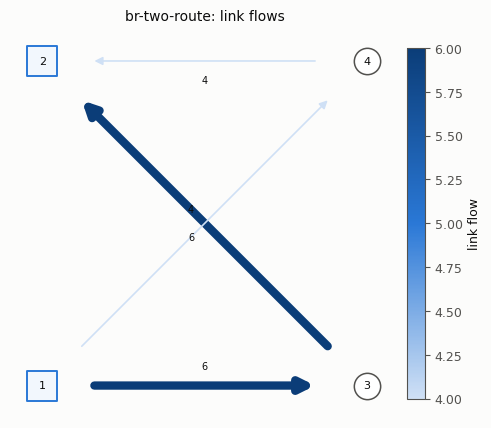

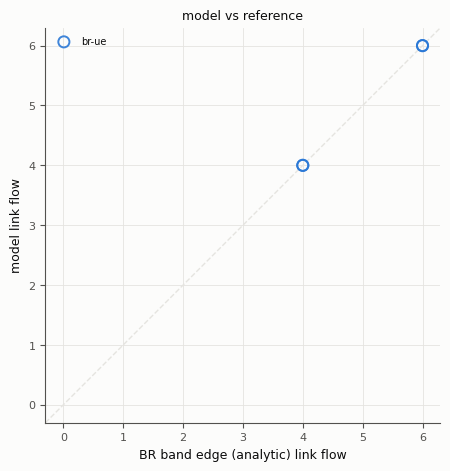

In [5]:
display(viz.plot_network_flows(net, final.link_flows))
display(viz.plot_flow_scatter(("BR band edge (analytic)", ref_flows), {"br-ue": final.link_flows}))

## Takeaways & pointers

- **The certificate is the band, not the gap.** `br_acceptable = 1` with AEC ≤ ε;
  the non-zero Wardrop gap is reported honestly, not hidden.
- **Set-valued equilibrium.** BR-UE is an acceptable *set*; ε → 0 recovers Wardrop.
- **Where next.** The exact-rationality UE: [`bfw`](05-bfw.ipynb); ADR-008 in the
  [model compendium](../../docs/MODELS.md).